# CityBikes API probe

This notebook helps you **inspect real CityBikes payloads** before we decide what schema to persist.

Docs: https://docs.citybik.es/api/

The public API is rate limited (docs mention **300 requests/hour**) and exposes rate-limit headers.

In [23]:
!pip install pyarrow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.3/34.3 MB 2.7 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
from __future__ import annotations

import json
import os
from urllib.request import Request, urlopen
from urllib.error import HTTPError, URLError

CITYBIKES_API_BASE = "https://api.citybik.es/v2"

CITYBIKES_API_KEY = os.getenv("CITYBIKES_API_KEY")  # optional; set in your env if you have one

def fetch_json(url: str, api_key: str | None = None, timeout_s: int = 30):
    headers = {"accept": "application/json"}
    if api_key:
        headers["x-api-key"] = api_key
    req = Request(url, headers=headers)
    try:
        with urlopen(req, timeout=timeout_s) as resp:
            data = json.loads(resp.read().decode("utf-8"))
            resp_headers = dict(resp.headers.items())
            return data, resp_headers
    except HTTPError as exc:
        body = exc.read().decode("utf-8", errors="replace") if hasattr(exc, "read") else ""
        raise RuntimeError(f"HTTP {exc.code} for {url}\n{body}") from exc
    except URLError as exc:
        raise RuntimeError(f"Network error fetching {url}: {exc}") from exc

def pretty(obj) -> str:
    return json.dumps(obj, indent=2, ensure_ascii=False)[:20000]  # cap for notebook readability

def show_rate_limit_headers(headers: dict):
    # header names vary in casing depending on client/server; normalize keys
    hk = {k.lower(): v for k, v in headers.items()}
    keys = [
        "x-ratelimit-limit-hour",
        "x-ratelimit-remaining-hour",
        "ratelimit-limit",
        "ratelimit-remaining",
        "ratelimit-reset",
    ]
    return {k: hk.get(k) for k in keys if k in hk}

print("Ready.")

Ready.


## 1) List networks

This endpoint returns a list of networks. We’ll use it to pick a `network.id` to probe deeper.

In [3]:
url = f"{CITYBIKES_API_BASE}/networks"
networks_payload, networks_headers = fetch_json(url, api_key=CITYBIKES_API_KEY)
print("Rate limit headers:", show_rate_limit_headers(networks_headers))
print("Top-level keys:", list(networks_payload.keys()))
print("Networks count:", len(networks_payload.get("networks") or []))

# Show a few example networks (id, name, location)
sample = (networks_payload.get("networks") or [])[:10]
for n in sample:
    loc = n.get("location") or {}
    print({
        "id": n.get("id"),
        "name": n.get("name"),
        "company": n.get("company"),
        "city": loc.get("city"),
        "country": loc.get("country"),
        "lat": loc.get("latitude"),
        "lon": loc.get("longitude"),
    })

Rate limit headers: {'x-ratelimit-limit-hour': '300', 'x-ratelimit-remaining-hour': '293', 'ratelimit-limit': '300', 'ratelimit-remaining': '293', 'ratelimit-reset': '1698'}
Top-level keys: ['networks']
Networks count: 801
{'id': 'abu-dhabi-careem-bike', 'name': 'Abu Dhabi Careem BIKE', 'company': ['Careem'], 'city': 'Abu Dhabi', 'country': 'AE', 'lat': 24.4866, 'lon': 54.3728}
{'id': 'acces-velo-saguenay', 'name': 'Accès Vélo', 'company': ['PBSC Urban Solutions'], 'city': 'Saguenay', 'country': 'CA', 'lat': 48.433333, 'lon': -71.083333}
{'id': 'aksu', 'name': 'Aksu', 'company': ['阿克苏公共服务'], 'city': '阿克苏市 (Aksu City)', 'country': 'CN', 'lat': 41.1664, 'lon': 80.2617}
{'id': 'alba', 'name': 'Alba', 'company': ['Comunicare S.r.l.'], 'city': 'Alba', 'country': 'IT', 'lat': 44.716667, 'lon': 8.083333}
{'id': 'albabici', 'name': 'AlbaBici', 'company': ['Instituto Tecnológico de Castilla y León (ITCL)'], 'city': 'Albacete', 'country': 'ES', 'lat': 38.9943, 'lon': -1.8602}
{'id': 'algira', 'n

## 2) Pick a network id to inspect

Set `NETWORK_ID` to one of the ids from above (e.g. a Spain system you care about).

In [4]:
NETWORK_ID = "bicimad"  # TODO: replace with whatever you want
NETWORK_ID

'bicimad'

## 3) Fetch one network (includes stations)

This returns `network` details including `network.stations`.

In [5]:
url = f"{CITYBIKES_API_BASE}/networks/{NETWORK_ID}"
network_payload, network_headers = fetch_json(url, api_key=CITYBIKES_API_KEY)
print("Rate limit headers:", show_rate_limit_headers(network_headers))
print("Top-level keys:", list(network_payload.keys()))
print("Network keys:", list((network_payload.get("network") or {}).keys()))

stations = (network_payload.get("network") or {}).get("stations") or []
print("Stations count:", len(stations))

# Show just the first station object (truncated) to inspect its fields
if stations:
    print(pretty(stations[0]))
else:
    print("No stations found for this network id.")

Rate limit headers: {'x-ratelimit-limit-hour': '300', 'x-ratelimit-remaining-hour': '292', 'ratelimit-limit': '300', 'ratelimit-remaining': '292', 'ratelimit-reset': '1650'}
Top-level keys: ['network']
Network keys: ['id', 'name', 'location', 'href', 'company', 'system', 'source', 'stations']
Stations count: 634
{
  "id": "01f5011f76069b1e81a11d4d51dd9d1d",
  "name": "377 - Metro Abrantes",
  "latitude": 40.38091762,
  "longitude": -3.72783615,
  "timestamp": "2026-03-24T09:31:36.348797+00:00Z",
  "free_bikes": 1,
  "empty_slots": 22,
  "extra": {
    "number": "377",
    "uid": 2153,
    "address": "Avenida De Abrantes, 55 ,",
    "online": true,
    "slots": 23,
    "light": "green"
  }
}


## 4) Field inventory across stations

Collect the union of keys across the first N stations to see what’s present/optional.

In [6]:
N = 200  # adjust
keys = set()
for st in stations[:N]:
    keys.update(st.keys())
print("Unique keys across first", min(N, len(stations)), "stations:")
print(sorted(keys))

# Count how often each key appears
counts = {k: 0 for k in keys}
for st in stations[:N]:
    for k in st.keys():
        counts[k] += 1

print("\nKey presence counts:")
for k in sorted(counts, key=lambda x: (counts[x], x)):
    print(f"{k:24s} {counts[k]:4d}/{min(N, len(stations))}")

Unique keys across first 200 stations:
['empty_slots', 'extra', 'free_bikes', 'id', 'latitude', 'longitude', 'name', 'timestamp']

Key presence counts:
empty_slots               200/200
extra                     200/200
free_bikes                200/200
id                        200/200
latitude                  200/200
longitude                 200/200
name                      200/200
timestamp                 200/200


## 5) Spot-check types / nested structures

This helps decide whether we store everything as JSON, or split a few stable columns (id, name, lat/lon, free/empty slots, timestamps, etc.).

In [7]:
def summarize_value(v):
    if isinstance(v, (str, int, float, bool)) or v is None:
        return type(v).__name__, v
    if isinstance(v, list):
        return "list", f"len={len(v)}; first_type={(type(v[0]).__name__ if v else None)}"
    if isinstance(v, dict):
        return "dict", f"keys={list(v.keys())[:20]}"
    return type(v).__name__, str(v)[:100]

if stations:
    st = stations[0]
    for k in sorted(st.keys()):
        t, info = summarize_value(st.get(k))
        print(f"{k:24s} {t:8s} {info}")

empty_slots              int      22
extra                    dict     keys=['number', 'uid', 'address', 'online', 'slots', 'light']
free_bikes               int      1
id                       str      01f5011f76069b1e81a11d4d51dd9d1d
latitude                 float    40.38091762
longitude                float    -3.72783615
name                     str      377 - Metro Abrantes
timestamp                str      2026-03-24T09:31:36.348797+00:00Z


## 6) Historical time series (monthly Parquet)

CityBikes publishes **historical station status changes** (time series) as **monthly Parquet** files on `data.citybik.es`.

Filename pattern (per their site):

- `{YYYY}{MM}-{network}-stats.parquet`

Example: `202411-bicing-stats.parquet`

We’ll download one month for your chosen `NETWORK_ID` and inspect the Parquet schema + sample rows.

In [20]:
from datetime import datetime
from pathlib import Path

DATA_CITYBIKES_BASE = "https://data.citybik.es/dumps/by-network"

# Choose a month to sample (defaults to previous month to avoid partial current-month data)
_now = datetime.utcnow()
_prev_month = datetime(_now.year, _now.month, 1)
# move back one day then to first of that month
_prev_month = datetime.fromtimestamp((_prev_month.timestamp() - 12*30*24*3600))
YYYY = f"{_prev_month.year}"
YYYYMM = f"{_prev_month.year}{_prev_month.month:02d}"

HIST_NETWORK_ID = NETWORK_ID  # you can override if historical naming differs

parquet_name = f"{YYYYMM}-{HIST_NETWORK_ID}-stats.parquet"
parquet_url = f"{DATA_CITYBIKES_BASE}/{YYYY}/{parquet_name}"
parquet_url

'https://data.citybik.es/dumps/by-network/2025/202503-bicimad-stats.parquet'

In [21]:
# Quick existence check (HEAD) before downloading
import urllib.request

req = urllib.request.Request(parquet_url, method="HEAD")
try:
    with urllib.request.urlopen(req, timeout=30) as r:
        print("✅ Found:", parquet_url)
        print("content-type:", r.headers.get("content-type"))
        print("content-length:", r.headers.get("content-length"))
        print("last-modified:", r.headers.get("last-modified"))
except Exception as e:
    print("❌ Could not HEAD file:", parquet_url)
    print("Error:", e)
    print("\nTry changing YYYYMM or HIST_NETWORK_ID.")

✅ Found: https://data.citybik.es/dumps/by-network/2025/202503-bicimad-stats.parquet
content-type: application/octet-stream
content-length: 3621974
last-modified: Wed, 02 Apr 2025 20:17:57 GMT


In [25]:
# Read Parquet schema + sample rows
#
# If you hit:
#   ArrowKeyError: No type extension with name arrow.py_extension_type found
# that's a pandas<->pyarrow extension-type mismatch.
# This cell uses PyArrow directly (and only converts to pandas optionally).

cache_dir = Path("../cache/citybikes_history")
cache_dir.mkdir(parents=True, exist_ok=True)
local_path = cache_dir / parquet_name

if not local_path.exists():
    print("⬇️ Downloading to", local_path)
    urllib.request.urlretrieve(parquet_url, local_path)
else:
    print("Using cached", local_path)

import pyarrow.parquet as pq

pf = pq.ParquetFile(local_path)
print("PyArrow schema:\n", pf.schema_arrow)
print("Row groups:", pf.num_row_groups)

# Read a small sample for inspection
sample_table = pf.read_row_group(0) if pf.num_row_groups else pf.read()
print("Columns:", sample_table.column_names)
print("\nSample rows (PyArrow):")
print(sample_table.slice(0, 5))

# Optional: convert a slice to pandas
try:
    import pandas as pd

    print("\nSample rows (pandas):")
    print(sample_table.slice(0, 5).to_pandas())
except Exception as e:
    print("\n(pandas conversion skipped)")
    print("Reason:", e)
    print("Fix: pip install --upgrade pyarrow pandas  (then restart kernel)")

Using cached ../cache/citybikes_history/202503-bicimad-stats.parquet
PyArrow schema:
 tag: string
id: string
nuid: string
name: string
latitude: double
longitude: double
bikes: int32
free: int32
extra: extension<arrow.json>
timestamp: timestamp[us]
Row groups: 10
Columns: ['tag', 'id', 'nuid', 'name', 'latitude', 'longitude', 'bikes', 'free', 'extra', 'timestamp']

Sample rows (PyArrow):
pyarrow.Table
tag: string
id: string
nuid: string
name: string
latitude: double
longitude: double
bikes: int32
free: int32
extra: extension<arrow.json>
timestamp: timestamp[us]
----
tag: [["bicimad","bicimad","bicimad","bicimad","bicimad"]]
id: [["01f5011f76069b1e81a11d4d51dd9d1d","01f5011f76069b1e81a11d4d51dd9d1d","01f5011f76069b1e81a11d4d51dd9d1d","01f5011f76069b1e81a11d4d51dd9d1d","01f5011f76069b1e81a11d4d51dd9d1d"]]
nuid: [["2153","2153","2153","2153","2153"]]
name: [["377 - Metro Abrantes","377 - Metro Abrantes","377 - Metro Abrantes","377 - Metro Abrantes","377 - Metro Abrantes"]]
latitude: [[40.

## 7) Plot historical time series (no pandas)

This section uses **PyArrow + Matplotlib** (no pandas) to:
- pick a station id column + timestamp column
- filter to one station
- sort by time
- plot `free_bikes` / `empty_slots` over time

In [28]:
import pyarrow.compute as pc
import matplotlib.pyplot as plt

# Choose likely column names (the historical schema can vary; we detect what exists)
cols = set(sample_table.column_names)

def pick_col(candidates):
    for c in candidates:
        if c in cols:
            return c
    return None

station_col = pick_col(["station_id", "id", "station", "station_uid", "uid"])
time_col = pick_col(["timestamp", "time", "datetime", "observed_at", "last_updated", "updated_at"])
free_col = pick_col(["free_bikes", "bikes", "available_bikes", "num_bikes_available"])
empty_col = pick_col(["empty_slots", "slots", "available_slots", "num_docks_available"])

print("Detected columns:")
print({
    "station_col": station_col,
    "time_col": time_col,
    "free_bikes_col": free_col,
    "empty_slots_col": empty_col,
})

if station_col is None or time_col is None:
    raise RuntimeError("Could not detect station/time columns. Check pf.schema_arrow output and update candidates.")

# Show a few station ids so you can pick one
station_vals = sample_table[station_col].to_pylist()
# Deduplicate while preserving order
seen = set()
examples = []
for v in station_vals:
    if v is None:
        continue
    if v in seen:
        continue
    seen.add(v)
    examples.append(v)
    if len(examples) >= 10:
        break
print("Example station ids:", examples)

Detected columns:
{'station_col': 'id', 'time_col': 'timestamp', 'free_bikes_col': 'bikes', 'empty_slots_col': None}
Example station ids: ['01f5011f76069b1e81a11d4d51dd9d1d', '025b1722c61309b46f4f3833c05d96a2', '0293685e90e89cbd15dfb4ae7db3551e', '02c587332ef68d67fa22a21b242fd857', '03616e7fc57d3e370fb9126349925d27', '03f33f7f29d1c6baddeffc240c7dce2a', '03ffff04a43ff9d80d751e07d3faf8a7', '04151db362cd348bd69553fd445ab165', '0421375b66b9538e3622294004e486ea', '045f23753c9948fb2942c8758f82c9b4']


In [29]:
# Pick a station id to plot
STATION_ID = examples[0] if examples else None
STATION_ID

'01f5011f76069b1e81a11d4d51dd9d1d'

Rows for station in month: 2756
Columns: ['id', 'timestamp', 'bikes']


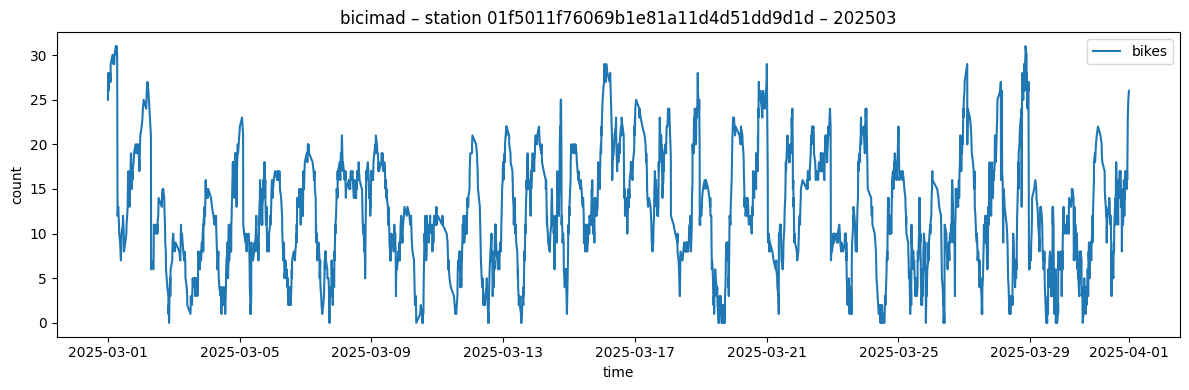

In [30]:
# Load ALL row groups for the station, then plot
# (If this month is huge, we can switch to scanning with pyarrow.dataset + filtering.)

pieces = []
for rg in range(pf.num_row_groups or 1):
    t = pf.read_row_group(rg)
    mask = pc.equal(t[station_col], STATION_ID)
    t2 = t.filter(mask)
    if t2.num_rows:
        # keep only columns we care about (if they exist)
        keep = [c for c in [station_col, time_col, free_col, empty_col] if c is not None and c in t2.column_names]
        pieces.append(t2.select(keep))

if not pieces:
    raise RuntimeError("No rows found for that station id in this month.")

station_table = pieces[0] if len(pieces) == 1 else pc.concat_tables(pieces)
print("Rows for station in month:", station_table.num_rows)
print("Columns:", station_table.column_names)

# Sort by time
sort_idx = pc.sort_indices(station_table, sort_keys=[(time_col, "ascending")])
station_table = station_table.take(sort_idx)

# Convert to Python lists for plotting (no pandas)
# Time column might be string or timestamp; matplotlib can plot python datetimes.
import datetime as _dt

time_vals = station_table[time_col].to_pylist()

# Try to parse ISO timestamps if they are strings
if time_vals and isinstance(time_vals[0], str):
    def _parse_iso(s):
        # Handles '2026-03-24T09:31:36.348797+00:00Z' style
        s = s.replace("Z", "+00:00")
        return _dt.datetime.fromisoformat(s)
    time_vals = [_parse_iso(x) for x in time_vals]

free_vals = station_table[free_col].to_pylist() if free_col in station_table.column_names else None
empty_vals = station_table[empty_col].to_pylist() if empty_col in station_table.column_names else None

plt.figure(figsize=(12, 4))
if free_vals is not None:
    plt.plot(time_vals, free_vals, label=free_col)
if empty_vals is not None:
    plt.plot(time_vals, empty_vals, label=empty_col)
plt.title(f"{HIST_NETWORK_ID} – station {STATION_ID} – {YYYYMM}")
plt.xlabel("time")
plt.ylabel("count")
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
# If the file is too large to load at once, use PyArrow to sample efficiently
try:
    import pyarrow.dataset as ds
    import pyarrow.parquet as pq

    table = pq.read_table(local_path, columns=None)
    print("PyArrow schema:")
    print(table.schema)

    # Show distinct station ids if present (column name varies; we'll search a few common options)
    cols = set(table.column_names)
    for c in ["station_id", "id", "station", "station_uid", "uid"]:
        if c in cols:
            arr = table[c].to_pandas()
            print("Example values for", c, ":", arr.dropna().astype(str).head(10).tolist())
            break
except ModuleNotFoundError:
    print("pyarrow not installed. If you need schema-level inspection without loading all rows, run: pip install pyarrow")

PyArrow schema:
tag: string
id: string
nuid: string
name: string
latitude: double
longitude: double
bikes: int32
free: int32
extra: extension<arrow.json>
timestamp: timestamp[us]
Example values for id : ['01f5011f76069b1e81a11d4d51dd9d1d', '01f5011f76069b1e81a11d4d51dd9d1d', '01f5011f76069b1e81a11d4d51dd9d1d', '01f5011f76069b1e81a11d4d51dd9d1d', '01f5011f76069b1e81a11d4d51dd9d1d', '01f5011f76069b1e81a11d4d51dd9d1d', '01f5011f76069b1e81a11d4d51dd9d1d', '01f5011f76069b1e81a11d4d51dd9d1d', '01f5011f76069b1e81a11d4d51dd9d1d', '01f5011f76069b1e81a11d4d51dd9d1d']
